In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import learning_curve, LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, SelectFromModel, SelectFpr, VarianceThreshold, chi2
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

In [4]:
dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df = pd.read_excel(dataset, sheet_name = 'Paul_50%_log2')

print(df.shape)

(24, 648)


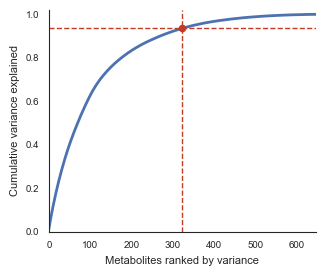

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Publication style (journal-ready)
# ===============================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,   # editable fonts in Illustrator
    "ps.fonttype": 42
})

sns.set_style("white")

# ===============================
# Compute cumulative variance
# ===============================
var_sorted = var.sort_values(ascending=False)
cum_var = np.cumsum(var_sorted) / np.sum(var_sorted)

# exact threshold
threshold = int(len(cum_var) * 0.5)
var_at_threshold = cum_var.iloc[threshold]

# ===============================
# Plot
# ===============================
fig, ax = plt.subplots(figsize=(3.3, 2.8))  # single column figure

# cumulative curve
ax.plot(
    range(len(cum_var)),
    cum_var,
    linewidth=2,
    color="#4C72B0"
)

# threshold lines
ax.axvline(
    x=threshold,
    color="#C23B22",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=var_at_threshold,
    color="#C23B22",
    linestyle="--",
    linewidth=1
)

# exact intersection point
ax.scatter(
    threshold,
    var_at_threshold,
    color="#C23B22",
    s=20,
    zorder=5
)

# labels
ax.set_xlabel("Metabolites ranked by variance")
ax.set_ylabel("Cumulative variance explained")

# limits
ax.set_xlim(0, len(cum_var))
ax.set_ylim(0, 1.02)

# clean axes
sns.despine()

plt.tight_layout()

# ===============================
# Export (vector, journal-ready)
# ===============================
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/ML feature selection/cumulative_variance_metabolites.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [22]:
dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df = pd.read_excel(dataset, sheet_name = 'Paul')

print(df.shape)

(24, 1295)


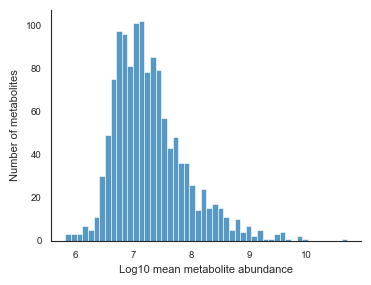

In [24]:
X = df.drop(columns=["Class"])
mean_abundance = X.mean(axis=0)


plt.figure(figsize=(4,3))
sns.histplot(np.log10(mean_abundance + 1), bins=50)

plt.xlabel("Log10 mean metabolite abundance")
plt.ylabel("Number of metabolites")

sns.despine()
plt.show()


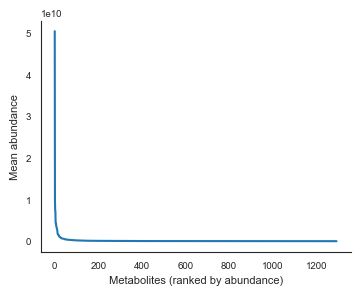

In [25]:
abundance_sorted = mean_abundance.sort_values(ascending=False)

plt.figure(figsize=(4,3))
plt.plot(range(len(abundance_sorted)), abundance_sorted)

plt.xlabel("Metabolites (ranked by abundance)")
plt.ylabel("Mean abundance")

sns.despine()
plt.show()

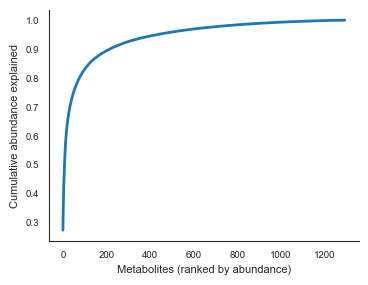

In [26]:
abundance_sorted = mean_abundance.sort_values(ascending=False)
cum_abundance = np.cumsum(abundance_sorted) / np.sum(abundance_sorted)

plt.figure(figsize=(4,3))

plt.plot(range(len(cum_abundance)), cum_abundance, linewidth=2)

plt.xlabel("Metabolites (ranked by abundance)")
plt.ylabel("Cumulative abundance explained")

sns.despine()
plt.show()